# 🚀 SpaceX Launch Success Analysis

## Project Overview
This project analyzes SpaceX Falcon 9 launch data to identify factors associated with successful first-stage landings.

The notebook follows a complete data science workflow:
1. Data collection from the SpaceX API and Wikipedia web scraping
2. Data cleaning and feature engineering
3. Exploratory data analysis and visualization
4. SQL-based analysis
5. Geographic launch-site analysis
6. Machine learning classification
7. Dashboard summary and final insights

## Key Questions
- Which launch sites have stronger landing-success performance?
- How do payload mass, orbit type, and launch site relate to landing outcome?
- Why are launch sites geographically positioned near coastlines and transportation infrastructure?
- How accurately can classification models predict first-stage landing success?

## 0. Imports and Project Paths

This section centralizes all imports and project paths to improve readability, reproducibility, and maintainability.

In [1]:
# Import libraries and define project paths

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import datetime
import sqlite3
from math import sin, cos, sqrt, atan2, radians

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from bs4 import BeautifulSoup

import folium
from folium.features import DivIcon
from folium.plugins import MarkerCluster

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

import sys
import prettytable

import unicodedata


# Project paths
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "figures"
MAP_DIR = PROJECT_ROOT / "outputs" / "maps"

DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MAP_DIR.mkdir(parents=True, exist_ok=True)


## 0.1 Visualization Settings

This section defines global chart styles, color palettes, and helper functions to keep the visualizations consistent across the notebook.

In [2]:
# Define global visualization settings, color palettes, and helper functions

PRIMARY_BLUE = "#4E79A7"
SUCCESS_GREEN = "#59A14F"
FAILURE_RED = "#E15759"
WARNING_ORANGE = "#F28E2B"
NEUTRAL_GRAY = "#B0B0B0"

outcome_palette = {
    "Success": SUCCESS_GREEN,
    "Failure": FAILURE_RED
}

bar_color = PRIMARY_BLUE

sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.edgecolor"] = NEUTRAL_GRAY
plt.rcParams["xtick.color"] = "#666666"
plt.rcParams["ytick.color"] = "#666666"
plt.rcParams["axes.labelcolor"] = "#555555"
plt.rcParams["text.color"] = "#333333"
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10


def format_xticks(rotation=0, ha="center"):
    """Format x-axis tick labels consistently."""
    plt.xticks(rotation=rotation, ha=ha)


def style_axes_text(
    spine_color="#CCCCCC",
    tick_color="#666666",
    label_color="#555555",
    title_color="#333333",
    despine=True
):
    """Apply consistent axis and text styling."""
    ax = plt.gca()
    
    for spine in ax.spines.values():
        spine.set_color(spine_color)
    
    ax.tick_params(axis="x", colors=tick_color)
    ax.tick_params(axis="y", colors=tick_color)
    ax.xaxis.label.set_color(label_color)
    ax.yaxis.label.set_color(label_color)
    ax.title.set_color(title_color)
    
    if despine:
        sns.despine()
        
    
def save_figure(filename, despine=True):
    """Save a matplotlib/seaborn figure using a consistent project output path."""
    if despine:
        sns.despine()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()


def add_bar_labels(values, offset=0.01, fmt="{:.2f}"):
    """Add value labels above bars in a bar chart."""
    for i, value in enumerate(values):
        plt.text(i, value + offset, fmt.format(value), ha="center")
        

## 1. Data Collection

This section loads a cleaned dataset if it already exists.  
If the cleaned dataset is not available, the notebook collects data from the SpaceX API, extracts relevant launch information, and saves a cleaned CSV file for reproducibility.

The API dataset is used as the primary source because it provides structured launch and landing information.

### 1.1 Data Collection from SpaceX API

This section collects SpaceX launch data from the SpaceX API and converts nested JSON fields into a structured dataframe.

In [3]:
# Define API caching and JSON request helper

CLEANED_DATA_PATH = DATA_DIR / "spacex_launches_cleaned.csv"

API_CACHE = {}

def get_json(url):
    """Fetch JSON data from an API endpoint with simple caching and error handling."""
    if url in API_CACHE:
        return API_CACHE[url]

    try:
        response = requests.get(url, timeout=20)
        response.raise_for_status()
        data = response.json()
        API_CACHE[url] = data
        return data
    except requests.exceptions.RequestException as error:
        print(f"API request failed: {url}")
        print(error)
        return {}
        

In [4]:
# Define functions to fetch and filter raw SpaceX API data

def fetch_raw_launch_data():
    """Collect past launch data from the SpaceX API."""
    url = "https://api.spacexdata.com/v4/launches/past"
    launches = get_json(url)
    return pd.json_normalize(launches)


def filter_single_core_single_payload_launches(data):
    """Keep launches with one core and one payload, then extract list values."""
    selected_columns = ["rocket", "payloads", "launchpad", "cores", "flight_number", "date_utc"]
    data = data[selected_columns].copy()

    data = data[data["cores"].map(len) == 1]
    data = data[data["payloads"].map(len) == 1]

    data["cores"] = data["cores"].map(lambda x: x[0])
    data["payloads"] = data["payloads"].map(lambda x: x[0])

    data["Date"] = pd.to_datetime(data["date_utc"]).dt.date

    # Match the original cutoff date for reproducibility
    data = data[data["Date"] <= datetime.date(2020, 11, 13)].copy()

    return data
    

In [5]:
# Define funtion to enrich launch records using related API endpoints

def build_launch_records(data):
    """Enrich launch rows with rocket, payload, launchpad, and core information."""
    records = []

    for _, row in data.iterrows():
        rocket = get_json(f"https://api.spacexdata.com/v4/rockets/{row['rocket']}")
        launchpad = get_json(f"https://api.spacexdata.com/v4/launchpads/{row['launchpad']}")
        payload = get_json(f"https://api.spacexdata.com/v4/payloads/{row['payloads']}")

        core_info = row["cores"]
        core = get_json(f"https://api.spacexdata.com/v4/cores/{core_info['core']}") if core_info.get("core") else {}

        outcome = f"{core_info.get('landing_success')} {core_info.get('landing_type')}"

        records.append({
            "FlightNumber": row["flight_number"],
            "Date": row["Date"],
            "BoosterVersion": rocket.get("name"),
            "PayloadMass": payload.get("mass_kg"),
            "Orbit": payload.get("orbit"),
            "LaunchSite": launchpad.get("name"),
            "Outcome": outcome,
            "Flights": core_info.get("flight"),
            "GridFins": core_info.get("gridfins"),
            "Reused": core_info.get("reused"),
            "Legs": core_info.get("legs"),
            "LandingPad": core_info.get("landpad"),
            "Block": core.get("block"),
            "ReusedCount": core.get("reuse_count"),
            "Serial": core.get("serial"),
            "Longitude": launchpad.get("longitude"),
            "Latitude": launchpad.get("latitude")
        })

    return pd.DataFrame(records)


def build_dataset():
    """Create the final Falcon 9 launch dataset from API data."""
    raw_data = fetch_raw_launch_data()
    filtered_data = filter_single_core_single_payload_launches(raw_data)
    launch_data = build_launch_records(filtered_data)

    # Keep Falcon 9 only
    data_falcon9 = launch_data[launch_data["BoosterVersion"] != "Falcon 1"]

    # Reset flight number for the filtered dataset
    data_falcon9 = data_falcon9.reset_index(drop=True)
    data_falcon9["FlightNumber"] = range(1, len(data_falcon9) + 1)

    data_falcon9.to_csv(CLEANED_DATA_PATH, index=False)
    print("Saved cleaned dataset.")

    return data_falcon9
    

In [6]:
# Load cleaned data if available, otherwise build the dataset from the API

if CLEANED_DATA_PATH.exists():
    data_falcon9 = pd.read_csv(CLEANED_DATA_PATH)
    print("Loaded cleaned dataset.")
else:
    data_falcon9 = build_dataset()

data_falcon9.head()


Saved cleaned dataset.


,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude
0,1,2010-06-04,Falcon 9,NaN,LEO,CCSFS SLC 40,None None,1,False,False,False,None,1.0,0,B0003,-80.577366,28.561857
1,2,2012-05-22,Falcon 9,525.0,LEO,CCSFS SLC 40,None None,1,False,False,False,None,1.0,0,B0005,-80.577366,28.561857
2,3,2013-03-01,Falcon 9,677.0,ISS,CCSFS SLC 40,None None,1,False,False,False,None,1.0,0,B0007,-80.577366,28.561857
3,4,2013-09-29,Falcon 9,500.0,PO,VAFB SLC 4E,False Ocean,1,False,False,False,None,1.0,0,B1003,-120.610829,34.632093
4,5,2013-12-03,Falcon 9,3170.0,GTO,CCSFS SLC 40,None None,1,False,False,False,None,1.0,0,B1004,-80.577366,28.561857


In [7]:
data_falcon9.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   FlightNumber    90 non-null     int64  
 1   Date            90 non-null     object 
 2   BoosterVersion  90 non-null     object 
 3   PayloadMass     85 non-null     float64
 4   Orbit           90 non-null     object 
 5   LaunchSite      90 non-null     object 
 6   Outcome         90 non-null     object 
 7   Flights         90 non-null     int64  
 8   GridFins        90 non-null     bool   
 9   Reused          90 non-null     bool   
 10  Legs            90 non-null     bool   
 11  LandingPad      64 non-null     object 
 12  Block           90 non-null     float64
 13  ReusedCount     90 non-null     int64  
 14  Serial          90 non-null     object 
 15  Longitude       90 non-null     float64
 16  Latitude        90 non-null     float64
dtypes: bool(3), float64(4), int64(3), obj

## 1.2 Web Scraping from Wikipedia

In addition to the SpaceX API, web scraping is used to collect supplementary Falcon 9 launch records from Wikipedia.

The scraped data is used as a reference source rather than the primary modeling dataset because web table formats may vary over time.

In [8]:
# Define helper functions for parsing Wikipedia launch table cells

def date_time(table_cells):
    values = [item.strip() for item in list(table_cells.strings)]
    return values[0:2]


def booster_version(table_cells):
    values = [booster for i, booster in enumerate(table_cells.strings) if i % 2 == 0]
    return "".join(values[0:-1]).strip()


def landing_status(table_cells):
    values = list(table_cells.strings)
    return values[0].strip() if values else None


def get_mass(table_cells):
    mass = unicodedata.normalize("NFKD", table_cells.text).strip()
    if "kg" in mass:
        return mass[:mass.find("kg") + 2]
    return None


def safe_link_text(cell):
    if cell.a and cell.a.string:
        return cell.a.string.strip()
    return cell.get_text(" ", strip=True)
    

In [9]:
# Define Wikipedia scraping function for structured Falcon launch records

def scrape_wikipedia_launch_table():
    url = "https://en.wikipedia.org/w/index.php?title=List_of_Falcon_9_and_Falcon_Heavy_launches&oldid=1027686922"
    headers = {"User-Agent": "Mozilla/5.0"}

    response = requests.get(url, headers=headers, timeout=20)
    response.raise_for_status()

    soup = BeautifulSoup(response.text, "html.parser")

    launch_dict = {
        "Flight No.": [],
        "Date": [],
        "Time": [],
        "Version Booster": [],
        "Launch site": [],
        "Payload": [],
        "Payload mass": [],
        "Orbit": [],
        "Customer": [],
        "Launch outcome": [],
        "Booster landing": []
    }

    tables = soup.find_all("table", "wikitable plainrowheaders collapsible")

    for table in tables:
        for row in table.find_all("tr"):
            if row.th and row.th.string:
                flight_number = row.th.string.strip()
                is_launch_row = flight_number.isdigit()
            else:
                is_launch_row = False

            cells = row.find_all("td")

            if is_launch_row and len(cells) >= 9:
                launch_dict["Flight No."].append(flight_number)

                dt = date_time(cells[0])
                launch_dict["Date"].append(dt[0].strip(",") if len(dt) > 0 else None)
                launch_dict["Time"].append(dt[1] if len(dt) > 1 else None)

                booster = booster_version(cells[1])
                if not booster and cells[1].a:
                    booster = cells[1].a.string
                launch_dict["Version Booster"].append(booster)

                launch_dict["Launch site"].append(safe_link_text(cells[2]))
                launch_dict["Payload"].append(safe_link_text(cells[3]))
                launch_dict["Payload mass"].append(get_mass(cells[4]))
                launch_dict["Orbit"].append(safe_link_text(cells[5]))
                launch_dict["Customer"].append(safe_link_text(cells[6]))

                launch_dict["Launch outcome"].append(list(cells[7].strings)[0])
                launch_dict["Booster landing"].append(landing_status(cells[8]))

    return pd.DataFrame(launch_dict)
    

In [10]:
# Scrape Wikipedia launch table and save the result as a CSV file

try:
    wiki_df = scrape_wikipedia_launch_table()

    wiki_df.to_csv(DATA_DIR / "spacex_web_scraped.csv", index=False)

    print("Wikipedia rows scraped:", wiki_df.shape[0])
    display(wiki_df.head())

except Exception as error:
    print("Web scraping failed:", error)
    wiki_df = pd.DataFrame()
    

Wikipedia rows scraped: 121


,Flight No.,Date,Time,Version Booster,Launch site,Payload,Payload mass,Orbit,Customer,Launch outcome,Booster landing
0,1,4 June 2010,18:45,F9 v1.07B0003.18,CCAFS,Dragon Spacecraft Qualification Unit,None,LEO,SpaceX,Success\n,Failure
1,2,8 December 2010,15:43,F9 v1.07B0004.18,CCAFS,Dragon,None,LEO,NASA,Success,Failure
2,3,22 May 2012,07:44,F9 v1.07B0005.18,CCAFS,Dragon,525 kg,LEO,NASA,Success,No attempt
3,4,8 October 2012,00:35,F9 v1.07B0006.18,CCAFS,SpaceX CRS-1,"4,700 kg",LEO,NASA,Success\n,No attempt
4,5,1 March 2013,15:10,F9 v1.07B0007.18,CCAFS,SpaceX CRS-2,"4,877 kg",LEO,NASA,Success\n,No attempt


In [11]:
wiki_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Flight No.       121 non-null    object
 1   Date             121 non-null    object
 2   Time             121 non-null    object
 3   Version Booster  121 non-null    object
 4   Launch site      121 non-null    object
 5   Payload          121 non-null    object
 6   Payload mass     116 non-null    object
 7   Orbit            121 non-null    object
 8   Customer         121 non-null    object
 9   Launch outcome   121 non-null    object
 10  Booster landing  121 non-null    object
dtypes: object(11)
memory usage: 10.5+ KB


## 2. Data Wrangling

This section prepares the launch dataset for analysis and modeling.

A binary variable `Class` is created for machine learning:
- `1 = Success`
- `0 = Failure`

A separate variable `OutcomeLabel` is created for visualization and dashboard display:
- `Success`
- `Failure`

Keeping `Outcome`, `Class`, and `OutcomeLabel` separate avoids mixing raw outcome descriptions, modeling labels, and presentation labels.

In [12]:
# Ensure Date is datetime
data_falcon9["Date"] = pd.to_datetime(data_falcon9["Date"])

# Fill missing PayloadMass values with the mean
data_falcon9["PayloadMass"] = data_falcon9["PayloadMass"].fillna(data_falcon9["PayloadMass"].mean())

# Define unsuccessful landing outcomes
bad_outcomes = {
    "False ASDS",
    "False Ocean",
    "False RTLS",
    "None ASDS",
    "None None"
}

# Create binary modeling target
data_falcon9["Class"] = data_falcon9["Outcome"].apply(lambda x: 0 if x in bad_outcomes else 1)

# Create readable label for visualization
data_falcon9["OutcomeLabel"] = data_falcon9["Class"].map({
    1: "Success",
    0: "Failure"
})

data_falcon9.head()


,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class,OutcomeLabel
0,1,2010-06-04,Falcon 9,6123.547647,LEO,CCSFS SLC 40,None None,1,False,False,False,None,1.0,0,B0003,-80.577366,28.561857,0,Failure
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCSFS SLC 40,None None,1,False,False,False,None,1.0,0,B0005,-80.577366,28.561857,0,Failure
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCSFS SLC 40,None None,1,False,False,False,None,1.0,0,B0007,-80.577366,28.561857,0,Failure
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,None,1.0,0,B1003,-120.610829,34.632093,0,Failure
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCSFS SLC 40,None None,1,False,False,False,None,1.0,0,B1004,-80.577366,28.561857,0,Failure


In [13]:
data_falcon9.isnull().sum().sort_values(ascending=False).head(15)

LandingPad        26
Date               0
FlightNumber       0
BoosterVersion     0
PayloadMass        0
LaunchSite         0
Orbit              0
Flights            0
GridFins           0
Reused             0
Outcome            0
Legs               0
Block              0
ReusedCount        0
Serial             0
dtype: int64

In [14]:
# Save the final cleaned dataset for dashboard and machine learning analysis

final_columns = [
    "FlightNumber",
    "Date",
    "BoosterVersion",
    "PayloadMass",
    "Orbit",
    "LaunchSite",
    "Outcome",
    "OutcomeLabel",
    "Class",
    "Flights",
    "GridFins",
    "Reused",
    "Legs",
    "LandingPad",
    "Block",
    "ReusedCount",
    "Serial",
    "Latitude",
    "Longitude"
]

final_df = data_falcon9[final_columns].copy()

final_df.to_csv(
    DATA_DIR / "spacex_launches_cleaned.csv",
    index=False
)

final_df.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,OutcomeLabel,Class,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Latitude,Longitude
0,1,2010-06-04,Falcon 9,6123.547647,LEO,CCSFS SLC 40,None None,Failure,0,1,False,False,False,None,1.0,0,B0003,28.561857,-80.577366
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCSFS SLC 40,None None,Failure,0,1,False,False,False,None,1.0,0,B0005,28.561857,-80.577366
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCSFS SLC 40,None None,Failure,0,1,False,False,False,None,1.0,0,B0007,28.561857,-80.577366
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,Failure,0,1,False,False,False,None,1.0,0,B1003,34.632093,-120.610829
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCSFS SLC 40,None None,Failure,0,1,False,False,False,None,1.0,0,B1004,28.561857,-80.577366


## 3. Exploratory Data Analysis

This section explores launch frequency, success rate, payload mass, orbit type, and launch sequence.

Each visualization is designed to answer one analytical question and is followed by a concise insight.

### 3.1 Launch Frequency by Site

This chart shows how often each launch site was used.

It helps identify the main operational locations for Falcon 9 launches.

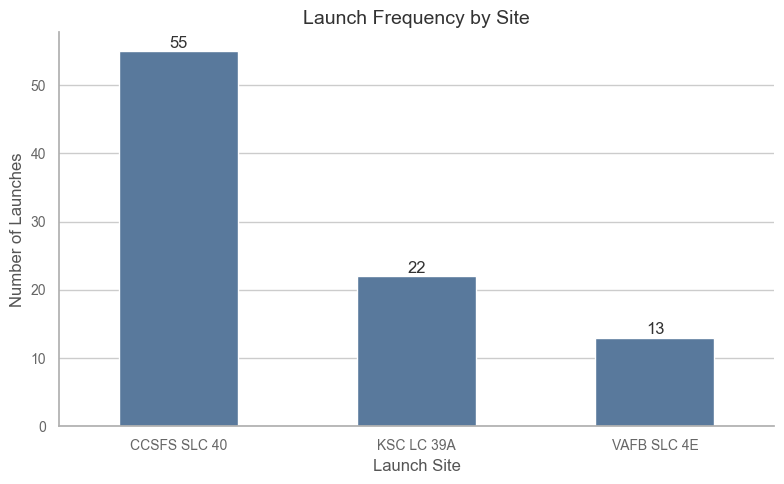

In [15]:
# Visualization the number of launches by site

site_counts = data_falcon9["LaunchSite"].value_counts().reset_index()
site_counts.columns = ["LaunchSite", "LaunchCount"]

sns.barplot(
    data=site_counts, 
    x="LaunchSite", 
    y="LaunchCount", 
    color=bar_color, 
    width=0.5
)

plt.title("Launch Frequency by Site")
plt.xlabel("Launch Site")
plt.ylabel("Number of Launches")

format_xticks()
add_bar_labels(site_counts["LaunchCount"], offset=0.5, fmt="{:.0f}")

save_figure("launch_frequency_by_site.png")


CCSFS SLC 40 is the most frequently used launch site, suggesting that a large share of SpaceX Falcon 9 launch activity was concentrated there during the project period.

### 3.2 Success Rate by Launch Site

This chart compares the average landing success rate across launch sites.

Because `Class` is coded as `1 = Success` and `0 = Failure`, the mean of `Class` represents the success rate.

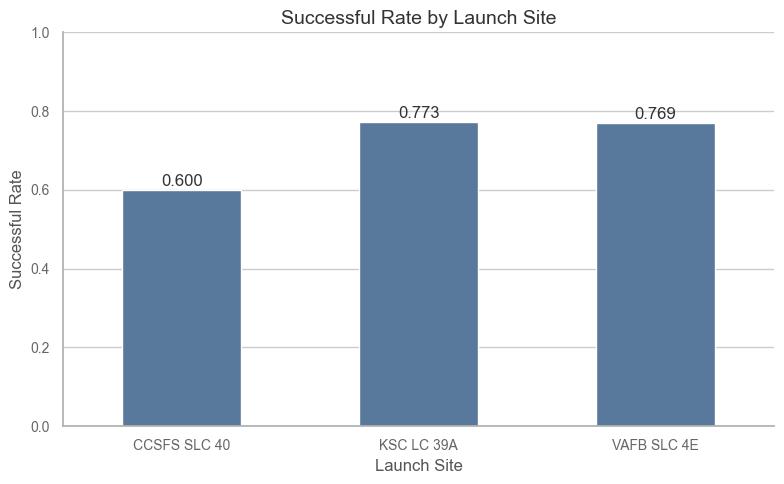

In [16]:
# Visualization average landing success rate by launch site

success_rate_by_site = (
    data_falcon9
    .groupby("LaunchSite")["Class"]
    .mean()
    .reset_index()
)

sns.barplot(
    data=success_rate_by_site, 
    x="LaunchSite", 
    y="Class", 
    color=bar_color, 
    width=0.5
)

plt.title("Successful Rate by Launch Site")
plt.xlabel("Launch Site")
plt.ylabel("Successful Rate")
plt.ylim(0, 1)

format_xticks()
add_bar_labels(success_rate_by_site["Class"], 0.01 , "{:.3f}")

save_figure("successful_rate_by_launch_site.png")


Success rates vary across launch sites, which suggests that site-specific operational conditions or mission profiles may be related to landing performance.

### 3.3 Flight Number vs Launch Site

This plot shows how launch-site usage changed as flight number increased.

It helps reveal whether SpaceX shifted or expanded launch operations over time.

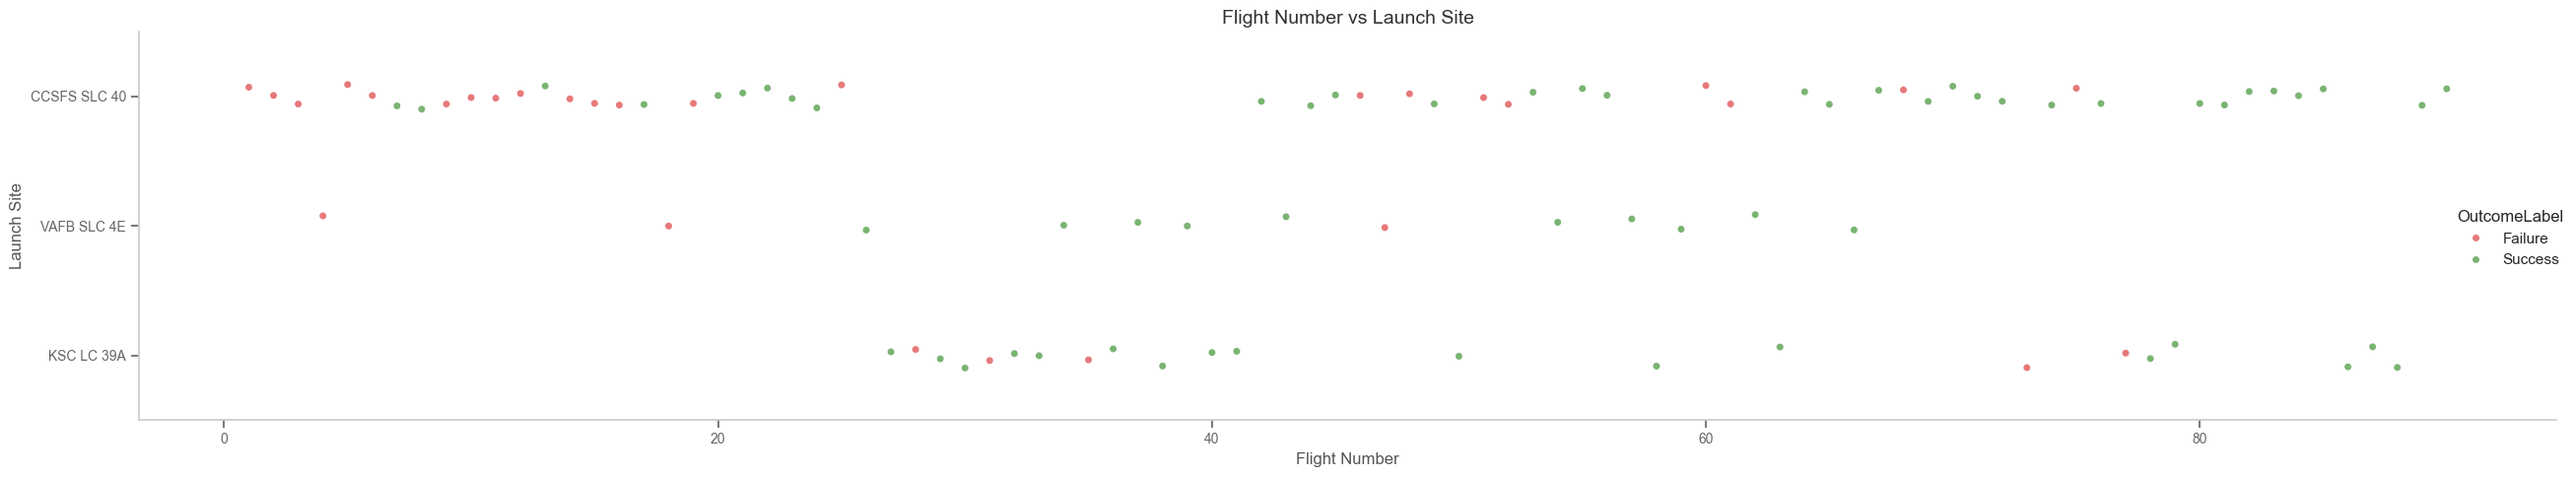

In [17]:
# Visualize launch site usage across flight number

with sns.axes_style("ticks"):
    sns.catplot(
        data=data_falcon9, 
        x="FlightNumber", 
        y="LaunchSite", 
        hue="OutcomeLabel", 
        palette=outcome_palette, 
        alpha=0.8,
        aspect=5
    )

    plt.title("Flight Number vs Launch Site")
    plt.xlabel("Flight Number")
    plt.ylabel("Launch Site")
    
    style_axes_text()
    save_figure("flight_number_vs_launch_site.png")
    

Launch-site usage changes over time, indicating operational shifts and expansion of launch capabilities as the Falcon 9 program matured.

### 3.4 Payload Mass vs Launch Site

This plot compares payload mass across launch sites.

It helps identify whether certain sites were more commonly used for heavier or lighter missions.

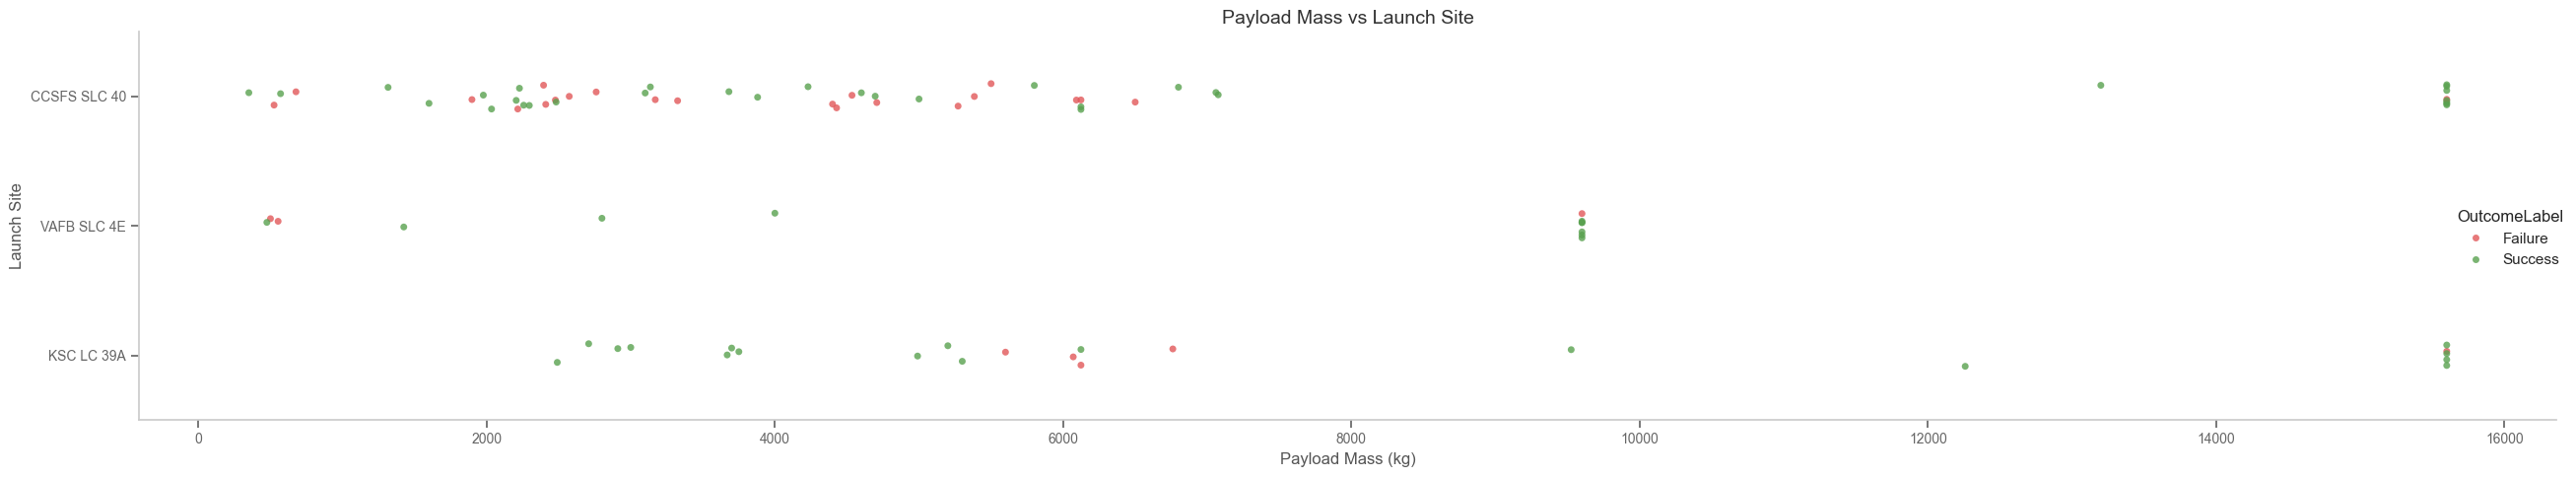

In [18]:
# Visualize payload mass distribution across launch sites

with sns.axes_style("ticks"):
    sns.catplot(
        data=data_falcon9, 
        x="PayloadMass", 
        y="LaunchSite", 
        hue="OutcomeLabel", 
        palette=outcome_palette, 
        alpha=0.8,
        aspect=5
    )
    
    plt.title("Payload Mass vs Launch Site")
    plt.xlabel("Payload Mass (kg)")
    plt.ylabel("Launch Site")
    
    style_axes_text()
    
    save_figure("payload_mass_vs_launch_site.png")
    

Payload mass differs across launch sites, suggesting that different sites may support different mission profiles and payload requirements.

### 3.5 Launch Outcome by Site

This chart compares the number of successful and failed landings at each launch site.

It complements the success-rate chart by showing the actual count distribution.

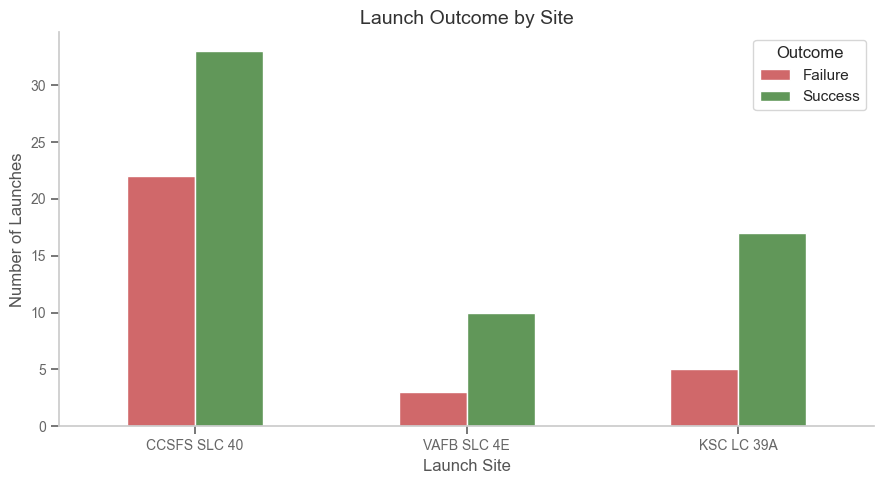

In [19]:
# Visualize success and failure counts by launch site

with sns.axes_style("ticks"):
    plt.figure(figsize=(9, 5))
    
    sns.countplot(
        data=data_falcon9, 
        x="LaunchSite", 
        hue="OutcomeLabel", 
        palette=outcome_palette, 
        width=0.5
    )
    
    plt.title("Launch Outcome by Site")
    plt.xlabel("Launch Site")
    plt.ylabel("Number of Launches")
    plt.legend(title="Outcome")

    style_axes_text()
    save_figure("launch_outcome_by_site.png")
    

The distribution of successful and failed landings varies by site, reinforcing that launch site is a useful feature for both analysis and modeling.

### 3.6 Flight Number vs Payload Mass

This plot explores how payload mass changes over time and how it relates to launch success.

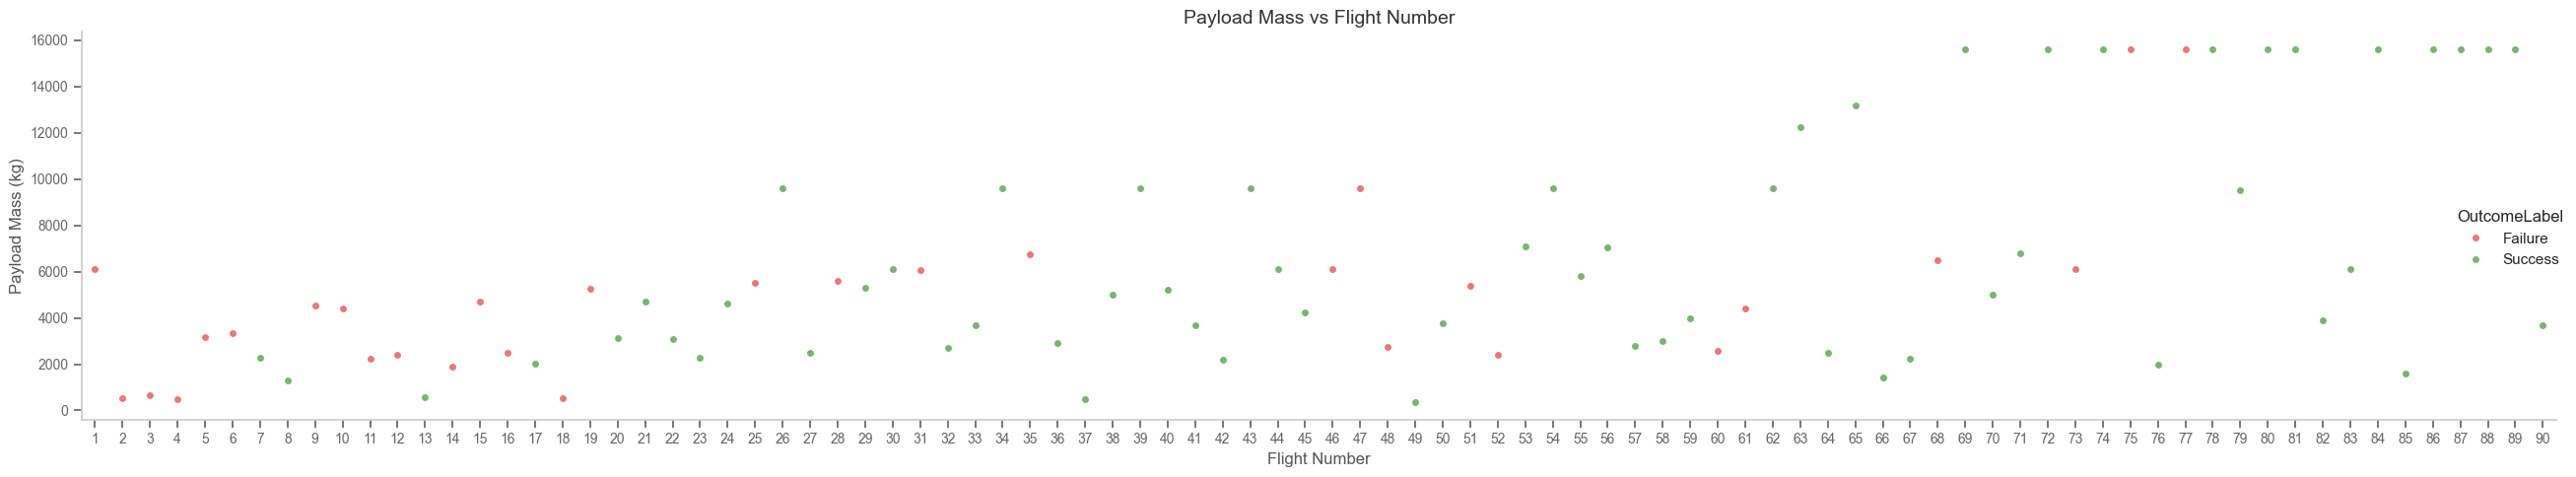

In [20]:
# Visualize payload mass across flight number and landing outcome

with sns.axes_style("ticks"):
    sns.catplot(
        data=data_falcon9,
        x="FlightNumber",
        y="PayloadMass",
        hue="OutcomeLabel",
        palette=outcome_palette,
        alpha=0.8,
        aspect=5
    )

    plt.title("Payload Mass vs Flight Number")
    plt.xlabel("Flight Number")
    plt.ylabel("Payload Mass (kg)")

    style_axes_text()
    
    save_figure("payload_mass_vs_flight_number.png")
    

Payload mass generally increases over time while successful outcomes become more common, reflecting operational learning and improvements in launch capability.

### 3.7 Payload Mass vs Launch Outcome

This boxplot compares payload mass distributions between successful and failed landings.

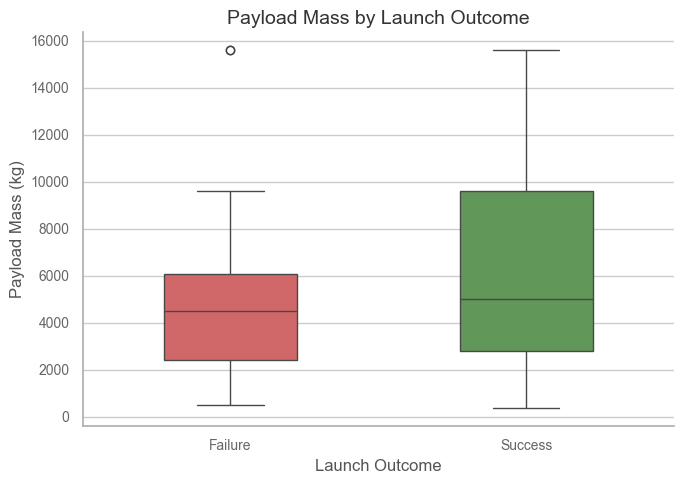

In [21]:
# Compare payload mass distributions by launch outcome

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=data_falcon9, 
    x="OutcomeLabel", 
    y="PayloadMass", 
    palette=outcome_palette, 
    width=0.45)

plt.title("Payload Mass by Launch Outcome")
plt.xlabel("Launch Outcome")
plt.ylabel("Payload Mass (kg)")
save_figure("payload_mass_by_outcome.png")


Payload mass alone does not clearly separate successful and failed landings, so it should be considered together with mission and booster-related variables.

### 3.8 Success Rate by Orbit Type

This chart examines how mission orbit type relates to landing success.

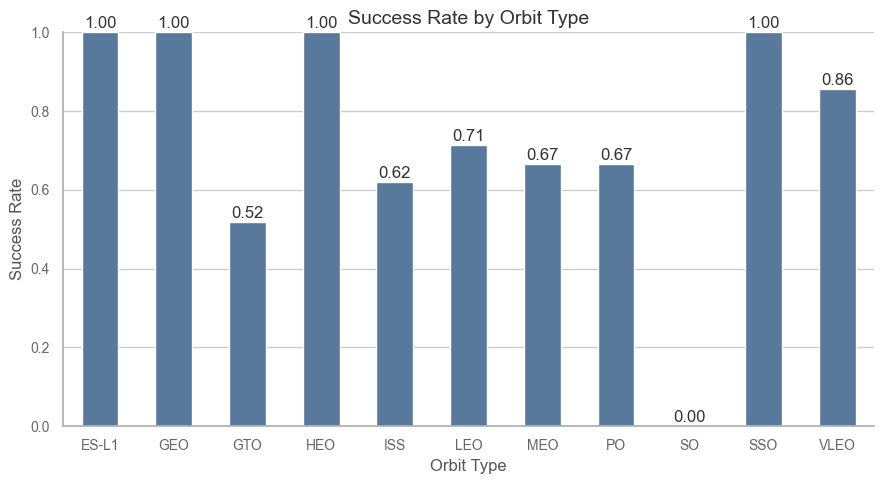

In [22]:
# Visualize average landing success rate by orbit type

orbit_success = (
    data_falcon9
    .groupby("Orbit")["Class"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=orbit_success, 
    x="Orbit", 
    y="Class", 
    color=bar_color, 
    width=0.5
)

plt.title("Success Rate by Orbit Type")
plt.xlabel("Orbit Type")
plt.ylabel("Success Rate")
plt.ylim(0, 1)

format_xticks()
add_bar_labels(orbit_success["Class"])

save_figure("success_rate_by_orbit_type.png")


Success rates vary across orbit types, suggesting that mission characteristics and orbital requirements may influence landing outcomes.

### 3.9 Flight Number vs Orbit Type

This plot shows how mission orbit types change over time.

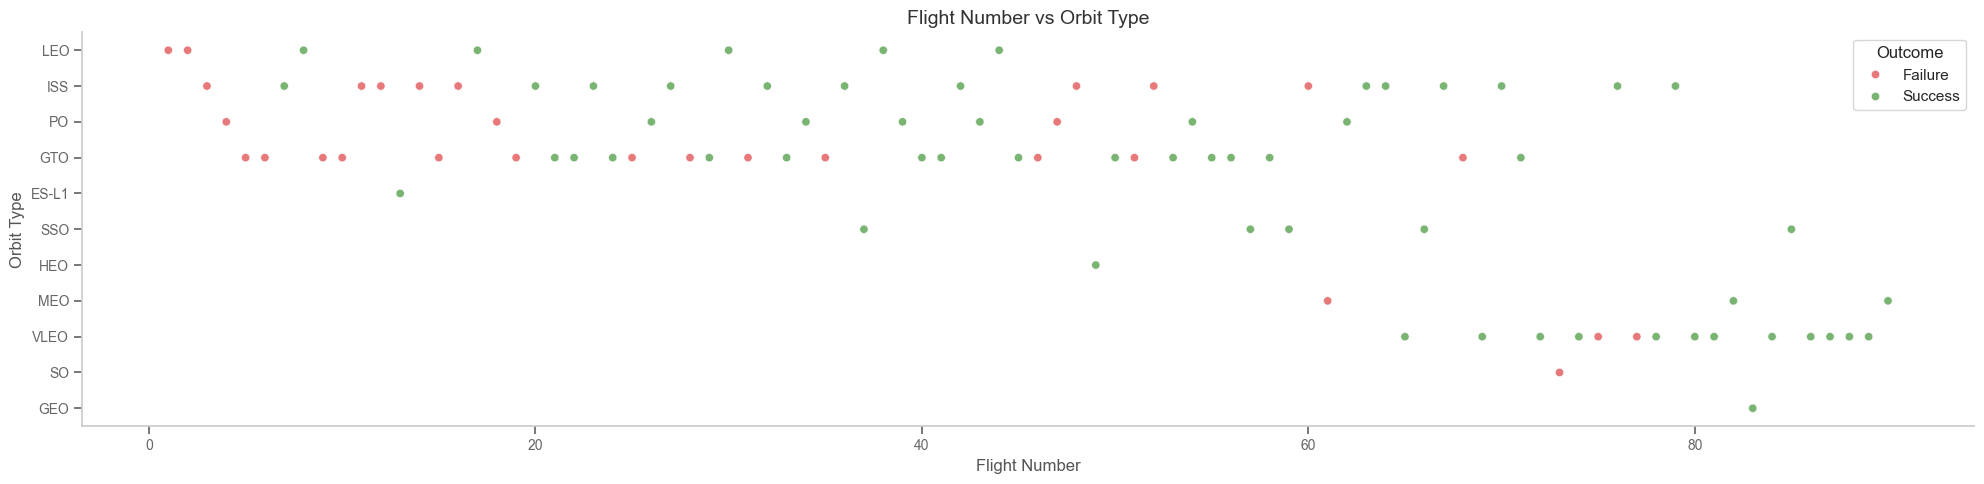

In [23]:
# Visualize orbit type across flight number

with sns.axes_style("ticks"):
    plt.figure(figsize=(20, 5))
    
    sns.scatterplot(
        data=data_falcon9, 
        x="FlightNumber", 
        y="Orbit", 
        hue="OutcomeLabel", 
        palette=outcome_palette, 
        alpha=0.8
    )
    
    plt.title("Flight Number vs Orbit Type")
    plt.xlabel("Flight Number")
    plt.ylabel("Orbit Type")
    plt.legend(title="Outcome")

    style_axes_text()
    
    save_figure("flight_number_vs_orbit_type.png")
    

Orbit distribution changes over time, indicating that SpaceX mission objectives and launch capabilities evolved during the project period.

### 3.10 Payload Mass vs Orbit Type

This plot compares payload mass across orbit types.

It helps connect mission profile with payload requirements.

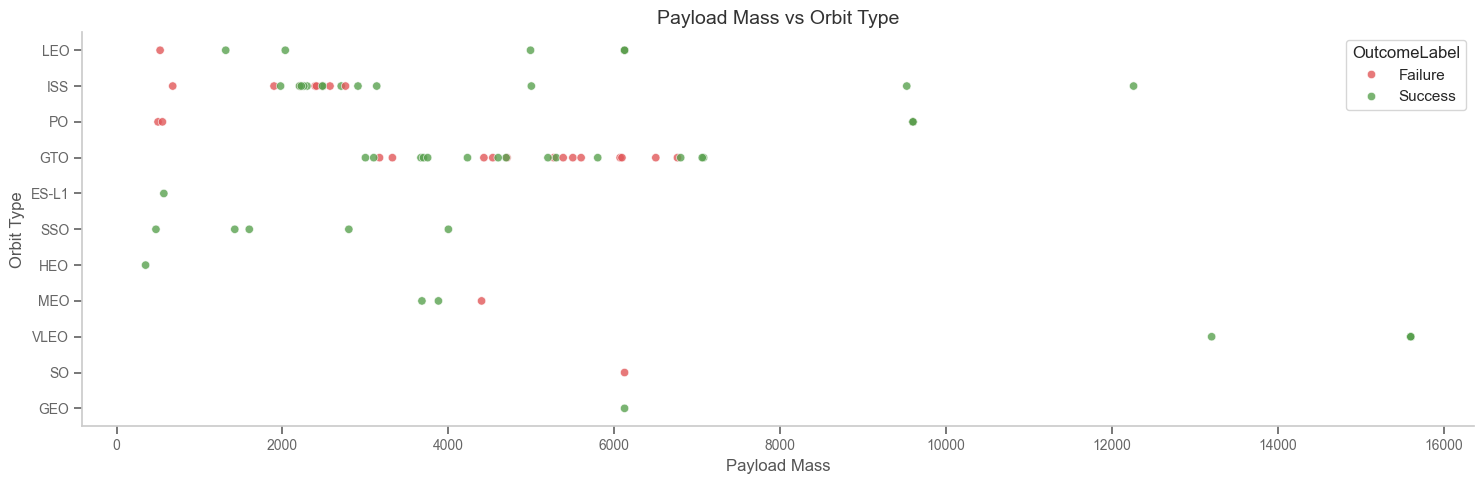

In [24]:
# Visualize payload mass across orbit type

with sns.axes_style("ticks"):
    plt.figure(figsize=(15, 5))
    
    sns.scatterplot(
        data=data_falcon9,
        x="PayloadMass", 
        y="Orbit", 
        hue="OutcomeLabel", 
        palette=outcome_palette, 
        alpha=0.8
    )
    
    plt.title("Payload Mass vs Orbit Type")
    plt.xlabel("Payload Mass")
    plt.ylabel("Orbit Type")

    style_axes_text()
    
    save_figure("payload_mass_vs_orbit_type.png")
    

 Different orbit types are associated with different payload mass ranges, reflecting different mission requirements and payload profiles.

### 3.11 Rolling Success Rate Over Time

This chart uses a rolling average to show how landing success changed over the launch sequence.

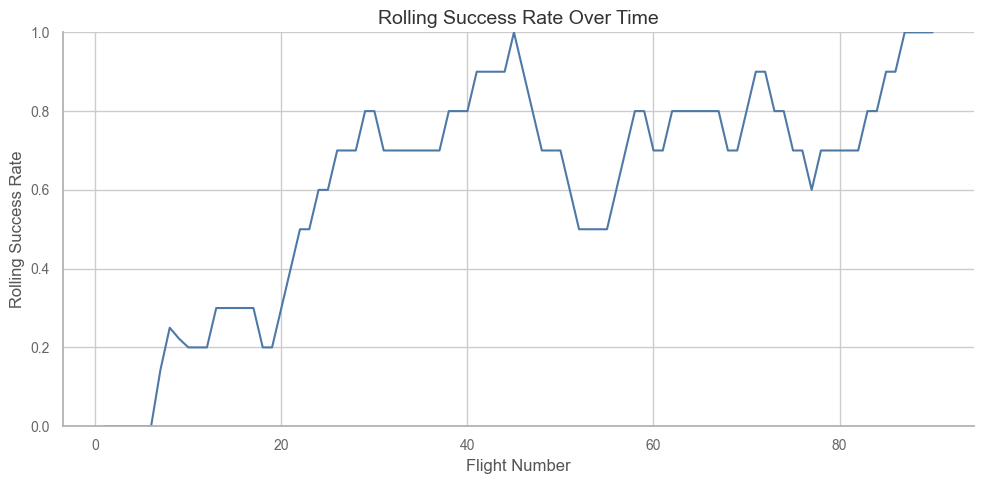

In [25]:
# Visualize rolling landing success rate over flight sequence

rolling_success = data_falcon9[["FlightNumber", "Class"]].copy()
rolling_success["RollingSuccessRate"] = rolling_success["Class"].rolling(window=10, min_periods=1).mean()

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=rolling_success, 
    x="FlightNumber", 
    y="RollingSuccessRate",
    color=bar_color
)

plt.title("Rolling Success Rate Over Time")
plt.xlabel("Flight Number")
plt.ylabel("Rolling Success Rate")
plt.ylim(0, 1)

save_figure("rolling_success_rate_over_time.png")


The rolling success rate improves over time, highlighting the impact of engineering iteration and operational learning.

### Overall EDA Insight

The exploratory analysis shows that launch success is associated with multiple factors, including launch site, orbit type, payload mass, and flight sequence.

Overall, the visualizations suggest that SpaceX improved both payload capability and landing performance over time, while mission-specific variables such as site and orbit remained important for understanding landing outcomes.

## 4. SQL-Style EDA

This section demonstrates SQL-based querying and aggregation using a local SQLite database.

The database is stored in the `data/` folder to keep project data files organized.

This section uses the `ipython-sql` extension, which allows interactive querying of SQLite databases directly within Jupyter notebooks.

If not installed, run:
!pip install ipython-sql

Then load the extension:

In [26]:
%load_ext sql

In [27]:
prettytable.DEFAULT = 'DEFAULT'

con = sqlite3.connect(DATA_DIR / "spacex_launches.db")
cur = con.cursor()

In [28]:
%sql sqlite:///../data/spacex_launches.db

In [29]:
data_falcon9.to_sql("SPACEXTBL", con, if_exists='replace', index=False, method="multi")

90

In [30]:
#DROP THE TABLE IF EXISTS
%sql DROP TABLE IF EXISTS SPACEXTABLE;

 * sqlite:///../data/spacex_launches.db
Done.


[]

In [31]:
%sql create table SPACEXTABLE as select * from SPACEXTBL where Date is not null

 * sqlite:///../data/spacex_launches.db
Done.


[]

In [32]:
# Display the names of the unique launch sites in the space mission
%sql select distinct LaunchSite from SPACEXTABLE

 * sqlite:///../data/spacex_launches.db
Done.


LaunchSite
CCSFS SLC 40
VAFB SLC 4E
KSC LC 39A


In [33]:
# Display 5 records where launch sites begin with the string 'CCS'
%sql select * from SPACEXTABLE where LaunchSite like 'CCS%' limit 5

 * sqlite:///../data/spacex_launches.db
Done.


FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class,OutcomeLabel
1,2010-06-04 00:00:00,Falcon 9,6123.547647058824,LEO,CCSFS SLC 40,None None,1,0,0,0,None,1.0,0,B0003,-80.577366,28.5618571,0,Failure
2,2012-05-22 00:00:00,Falcon 9,525.0,LEO,CCSFS SLC 40,None None,1,0,0,0,None,1.0,0,B0005,-80.577366,28.5618571,0,Failure
3,2013-03-01 00:00:00,Falcon 9,677.0,ISS,CCSFS SLC 40,None None,1,0,0,0,None,1.0,0,B0007,-80.577366,28.5618571,0,Failure
5,2013-12-03 00:00:00,Falcon 9,3170.0,GTO,CCSFS SLC 40,None None,1,0,0,0,None,1.0,0,B1004,-80.577366,28.5618571,0,Failure
6,2014-01-06 00:00:00,Falcon 9,3325.0,GTO,CCSFS SLC 40,None None,1,0,0,0,None,1.0,0,B1005,-80.577366,28.5618571,0,Failure


In [34]:
# Display average payload mass carried by LaunchSite KSC LC 39A
%sql select avg(PayloadMass) as Avg_Payload_Mass from SPACEXTABLE where LaunchSite = "KSC LC 39A"

 * sqlite:///../data/spacex_launches.db
Done.


Avg_Payload_Mass
7644.504331550802


In [35]:
# List the date when the first landing to a ground pad was achieved
%sql select min(Date) as First_Succesful_Landing from SPACEXTABLE where Outcome = "True RTLS"

 * sqlite:///../data/spacex_launches.db
Done.


First_Succesful_Landing
2015-12-22 00:00:00


In [36]:
# List the names of the Orbits which have success in drone ship and have payload mass greater than 4000 but less than 6000
%sql select distinct Orbit from SPACEXTABLE where Outcome = "True ASDS" and PayloadMass > 4000 and PayloadMass < 6000

 * sqlite:///../data/spacex_launches.db
Done.


Orbit
GTO
ISS


In [37]:
# List the total number of successful and failure mission outcomes
%sql select Class, count(*) as Total_Mission_Outcome from SPACEXTABLE group by Class

 * sqlite:///../data/spacex_launches.db
Done.


Class,Total_Mission_Outcome
0,30
1,60


In [38]:
# List all the launch sites that have carried the maximum payload mass
%sql select distinct LaunchSite from SPACEXTABLE where PayloadMass = (select max(PayloadMass) from SPACEXTABLE)

 * sqlite:///../data/spacex_launches.db
Done.


LaunchSite
CCSFS SLC 40
KSC LC 39A


In [39]:
# List the records which will display the month names, failure outcomes, launch_site for the months in year 2015
%sql select substr(Date, 6, 2) as Month, Outcome, LaunchSite from SPACEXTABLE where substr(Date, 1, 4) = '2015' and Class=0

 * sqlite:///../data/spacex_launches.db
Done.


Month,Outcome,LaunchSite
01,False ASDS,CCSFS SLC 40
04,False ASDS,CCSFS SLC 40
04,None None,CCSFS SLC 40
06,None ASDS,CCSFS SLC 40


In [40]:
# Rank the count of outcomes between the date 2010-06-04 and 2017-03-20, in descending order
%sql select Outcome, count(*) as Count_Landing_Outcome from SPACEXTABLE where Date between '2010-06-04' and '2017-03-20' group by Outcome order by Count_Landing_Outcome DESC

 * sqlite:///../data/spacex_launches.db
Done.


Outcome,Count_Landing_Outcome
None None,9
True ASDS,5
False ASDS,4
True RTLS,3
True Ocean,3
None ASDS,2
False Ocean,2


## 5. Launch Site Geographic Visualization

This section uses three Folium maps to explain launch-site geography at different scales:

1. **Global Overview Map**: NASA Johnson Space Center, all launch sites, launch distribution, and infrastructure context  
2. **Florida Regional Map**: CCSFS SLC 40 and KSC LC 39A, shown together because they are geographically close  
3. **California Regional Map**: VAFB SLC 4E as a separate regional view  

Each map combines site markers, launch outcome distribution, and distance lines to nearby infrastructure.

In [41]:
# Prepare launch site data, NASA location, nearest infrastructure points, and map colors

launch_sites_df = (
    data_falcon9
    .groupby(['LaunchSite'], as_index=False)
    .first()[['LaunchSite', 'Latitude', 'Longitude']]
)

nasa_coordinate = [29.559684888503615, -95.0830971930759]

nearest_points = {
    "CCSFS SLC 40": {
        "coastline": (28.56392, -80.56805),
        "city": (28.39684, -80.60566),
        "railway": (28.56443, -80.58670),
        "highway": (28.56372, -80.57086)
    },
    "KSC LC 39A": {
        "coastline": (28.61256, -80.59799),
        "city": (28.39684, -80.60566),
        "railway": (28.57210, -80.65300),
        "highway": (28.57250, -80.65500)
    },
    "VAFB SLC 4E": {
        "coastline": (34.63504, -120.62508),
        "city": (34.63910, -120.45790),
        "railway": (34.63554, -120.62400),
        "highway": (34.66470, -120.45760)
    }
}

proximity_colors = {
    "coastline": WARNING_ORANGE,
    "city": PRIMARY_BLUE,
    "railway": "#B07AA1",
    "highway": NEUTRAL_GRAY
}

map_outcome_colors = {
    "Success": SUCCESS_GREEN,
    "Failure": FAILURE_RED
}

launch_sites_df


,LaunchSite,Latitude,Longitude
0,CCSFS SLC 40,28.561857,-80.577366
1,KSC LC 39A,28.608058,-80.603956
2,VAFB SLC 4E,34.632093,-120.610829


In [42]:
# Define reusable helper functions for launch-site maps

def get_site_center(site_name, launch_sites_df):
    """Return the latitude and longitude center for one launch site."""
    row = launch_sites_df[
        launch_sites_df["LaunchSite"] == site_name
    ].iloc[0]

    return [row["Latitude"], row["Longitude"]]


def get_map_bounds(launch_sites_subset, nearest_points):
    """Collect coordinates used to automatically fit a Folium map."""
    coords = [nasa_coordinate]

    for _, row in launch_sites_subset.iterrows():
        coords.append([row["Latitude"], row["Longitude"]])

        site_name = row["LaunchSite"]
        if site_name in nearest_points:
            for point in nearest_points[site_name].values():
                coords.append(list(point))

    return coords


def create_nasa_marker(site_map):
    """Add NASA Johnson Space Center marker and label."""
    marker = folium.map.Marker(
        nasa_coordinate,
        icon=DivIcon(
            icon_size=(50,20),
            icon_anchor=(-2,-2),
            html='<div style="font-size: 12; color:PRIMARY_BLUE;"><b>%s</b></div>' % 'NASA JSC',
        )
    )
    site_map.add_child(marker)

    folium.Marker(
        nasa_coordinate,
        tooltip="NASA Johnson Space Center",
        icon=folium.Icon(color="blue", icon="info-sign")
    ).add_to(site_map)


def create_site_markers(site_map):
    for _, site in launch_sites_df.iterrows():
        site_name = site["LaunchSite"]

        folium.Marker(
            location=[site["Latitude"], site["Longitude"]],
            tooltip=site_name,
            icon=folium.Icon(color="blue", icon="rocket", prefix="fa")
        ).add_to(site_map)


In [43]:
# Define reusable functions for launch distribution and distance lines

def create_launches_for_sites(site_map):
    # Mark the success/failed launches for each site on the map

    marker_cluster = MarkerCluster()

    data_falcon9['marker_color'] = data_falcon9['Class'].apply(lambda x: SUCCESS_GREEN if x == 1 else FAILURE_RED)

    site_map.add_child(marker_cluster)

    for index, record in data_falcon9.iterrows():

        coordinate = [record['Latitude'], record['Longitude']]
    
        popup_text = (
            f"Date: {record['Date'].date()}<br>"
            f"Site: {record['LaunchSite']}<br>"
            f"Outcome: {record['OutcomeLabel']}"
        )
    
        marker = folium.Marker(
            location = coordinate,
            icon = folium.Icon(
                color = 'white',
                icon_color = record['marker_color']
            ),
            popup=folium.Popup(popup_text, max_width=250)
        )

        marker_cluster.add_child(marker)


def get_site_center(site_name, launch_sites_df):

    row = launch_sites_df[launch_sites_df["LaunchSite"] == site_name].iloc[0]

    return [row["Latitude"],row["Longitude"]]


def calculate_distance(lat1, lon1, lat2, lon2):
    R = 6373.0  # Earth radius in km

    lat1 = radians(lat1)
    lon1 = radians(lon1)
    lat2 = radians(lat2)
    lon2 = radians(lon2)

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    return R * c


# Draw lines and calculate distances
def draw_lines_and_calculate_distances(site_map, launch_sites_df, nearest_points):
    distance_results = []

    site_col = "Launch Site" if "Launch Site" in launch_sites_df.columns else "LaunchSite"

    for _, row in launch_sites_df.iterrows():
        site_name = row[site_col]
        site_lat = row["Latitude"]
        site_lon = row["Longitude"]

        if site_name not in nearest_points:
            print(f"Warning: No nearest point data for {site_name}")
            continue

        result = {
            "Launch Site": site_name,
            "Latitude": site_lat,
            "Longitude": site_lon
        }

        for proximity_type, (target_lat, target_lon) in nearest_points[site_name].items():

            # Calculate distance
            distance = calculate_distance(site_lat, site_lon, target_lat, target_lon)
            result[f"Distance to {proximity_type.title()} (km)"] = distance

            # Draw line
            color = proximity_colors.get(proximity_type, "gray")

            folium.PolyLine(
                locations=[[site_lat, site_lon], [target_lat, target_lon]],
                weight=2,
                color=color,
                opacity=0.8
            ).add_to(site_map)

            # Add target marker
            folium.CircleMarker(
                location=[target_lat, target_lon],
                radius=4,
                color=color,
                fill=True,
                fill_color=color,
                popup=f"Nearest {proximity_type.title()} for {site_name}"
            ).add_to(site_map)

            # Add distance label at midpoint
            mid_lat = (site_lat + target_lat) / 2
            mid_lon = (site_lon + target_lon) / 2

            folium.Marker(
                location=[mid_lat, mid_lon],
                icon=DivIcon(
                    icon_size=(60, 36),
                    icon_anchor=(0, 0),
                    html=f"""
                    <div style="
                        font-size: 12px;
                        color: {color};
                        font-weight: bold;
                        background-color: rgba(255,255,255,0.75);
                        padding: 2px 4px;
                        border-radius: 4px;">
                        {distance:.2f} km
                    </div>
                    """
                )
            ).add_to(site_map)

        distance_results.append(result)

    # Create distance summary table
    distance_df = pd.DataFrame(distance_results).round(2)

    return distance_df

In [44]:
# Define the main reusable function for global and regional launch-site maps

def create_launch_site_map(center, zoom_start, launch_sites_df, nearest_points):
    m = folium.Map(
        location=center,
        zoom_start=zoom_start,
        tiles="OpenStreetMap"
    )

    create_nasa_marker(m)

    create_site_markers(m)

    create_launches_for_sites(m)
    
    distance_df = draw_lines_and_calculate_distances(m, launch_sites_df, nearest_points)

    return m

In [45]:
# Create global and site-detail maps

site_map = create_launch_site_map(
    center=nasa_coordinate,
    zoom_start=5,
    launch_sites_df=launch_sites_df,
    nearest_points=nearest_points
)

# Make sure all sites and target are displayed
all_coords = []

for _, row in launch_sites_df.iterrows():
    all_coords.append((row["Latitude"], row["Longitude"]))

for site in nearest_points.values():
    for point in site.values():
        all_coords.append(point)

site_map.fit_bounds(all_coords)

site_map.save(MAP_DIR / "site_global_map.html")

site_map

In [46]:
# Create Florida sites map

site_florida_map = create_launch_site_map(
    center=get_site_center("CCSFS SLC 40", launch_sites_df),
    zoom_start=11,
    launch_sites_df=launch_sites_df,
    nearest_points=nearest_points,
)

site_florida_map.save(MAP_DIR / "site_florida_map.html")

site_florida_map

The Florida launch sites are geographically close and share similar coastal infrastructure. A regional map is more effective than a national-scale map for comparing CCSFS SLC 40 and KSC LC 39A.

In [47]:
# Create California site map

site_california_map = create_launch_site_map(
    center=get_site_center("VAFB SLC 4E", launch_sites_df),
    zoom_start=11,
    launch_sites_df=launch_sites_df,
    nearest_points=nearest_points,
)

site_california_map.save(MAP_DIR / "site_california_map.html")

site_california_map

Launch sites are generally close to coastlines, which supports launch safety by reducing risk to populated areas. At the same time, reasonable access to cities, highways, and railways supports launch operations and logistics.

## 6. Machine Learning Preparation

This section prepares the dataset for classification modeling.

The workflow intentionally splits the data before scaling to avoid data leakage.

In [48]:
# Select features, handle missing values, encode categorical variables, and define the modeling target

feature_cols = [
    "FlightNumber", "PayloadMass", "Flights", "GridFins", "Reused", "Legs",
    "Block", "ReusedCount", "Orbit", "LaunchSite", "LandingPad", "Serial"
]

available_features = [col for col in feature_cols if col in data_falcon9.columns]
model_df = data_falcon9[available_features + ["Class"]].copy()

for col in model_df.columns:
    if model_df[col].dtype == "object":
        model_df[col] = model_df[col].fillna("None")
    else:
        model_df[col] = model_df[col].fillna(model_df[col].mean())

X = pd.get_dummies(model_df.drop("Class", axis=1))
y = model_df["Class"]

print("Feature matrix shape:", X.shape)
print("Target distribution:")
print(y.value_counts())

Feature matrix shape: (90, 81)
Target distribution:
Class
1    60
0    30
Name: count, dtype: int64


In [49]:
# Split data before scaling to avoid data leakage, then scale train and test features

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (72, 81)
X_test shape: (18, 81)


## 7. Classification Models & Evaluation

This section trains and compares four classification models using GridSearchCV.

The comparison uses cross-validation accuracy and test accuracy. If two models have the same test accuracy, the notebook reports the tie instead of implying that one model is clearly better.

In [50]:
model_configs = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000),
        "params": {"C": [0.01, 0.1, 1], "penalty": ["l2"], "solver": ["lbfgs"]},
        "use_scaled": True
    },
    "SVM": {
        "model": SVC(),
        "params": {"kernel": ["linear", "rbf", "poly", "sigmoid"], "C": np.logspace(-3, 3, 5), "gamma": np.logspace(-3, 3, 5)},
        "use_scaled": True
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(random_state=42),
        "params": {
            "criterion": ["gini", "entropy"],
            "splitter": ["best", "random"],
            "max_depth": [2 * n for n in range(1, 10)],
            "max_features": ["sqrt", "log2", None],
            "min_samples_leaf": [1, 2, 4],
            "min_samples_split": [2, 5, 10]
        },
        "use_scaled": False
    },
    "KNN": {
        "model": KNeighborsClassifier(),
        "params": {"n_neighbors": list(range(1, 11)), "algorithm": ["auto", "ball_tree", "kd_tree", "brute"], "p": [1, 2]},
        "use_scaled": True
    }
}

In [51]:
# Train and tune classification models using GridSearchCV

results = {}

for model_name, config in model_configs.items():
    print(f"Training {model_name}...")
    
    X_train_input = X_train_scaled if config["use_scaled"] else X_train
    X_test_input = X_test_scaled if config["use_scaled"] else X_test
    
    grid = GridSearchCV(
        estimator=config["model"], 
        param_grid=config["params"], 
        cv=10, 
        scoring="accuracy"
    )
    
    grid.fit(X_train_input, y_train)
    
    results[model_name] = {
        "best_params": grid.best_params_,
        "cv_accuracy": grid.best_score_,
        "test_accuracy": grid.score(X_test_input, y_test),
        "best_model": grid.best_estimator_,
        "use_scaled": config["use_scaled"]
    }

results_df = pd.DataFrame({
    model_name: {"CV Accuracy": result["cv_accuracy"], "Test Accuracy": result["test_accuracy"]}
    for model_name, result in results.items()
}).T

results_df

Training Logistic Regression...
Training SVM...
Training Decision Tree...
Training KNN...


,CV Accuracy,Test Accuracy
Logistic Regression,0.850000,0.833333
SVM,0.850000,0.833333
Decision Tree,0.891071,0.722222
KNN,0.864286,0.722222


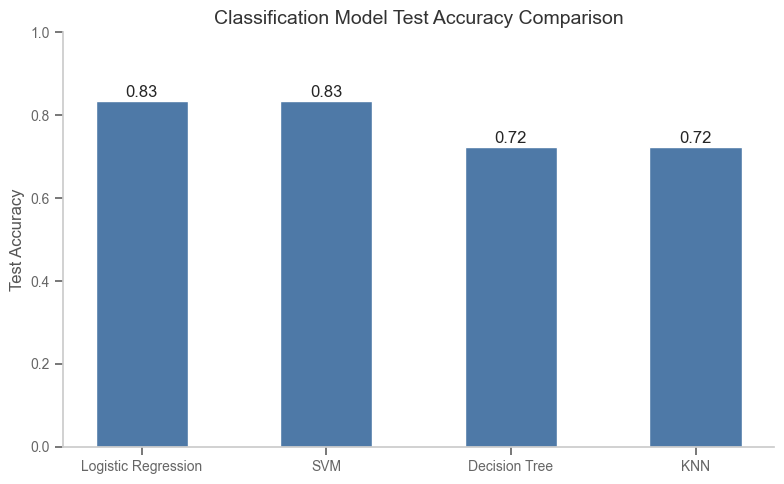

In [52]:
# Visualize test accuracy for each classification model

with sns.axes_style("ticks"):
    plt.figure(figsize=(8, 5))
    
    plt.bar(results_df.index, results_df["Test Accuracy"], color=PRIMARY_BLUE, width=0.5)
    plt.title("Classification Model Test Accuracy Comparison")
    plt.ylabel("Test Accuracy")
    
    for i, score in enumerate(results_df["Test Accuracy"]):
        plt.text(i, score + 0.01, f"{score:.2f}", ha="center")
    
    plt.ylim(0, 1)
    
    style_axes_text()
    
    save_figure("classification_model_accuracy.png")


In [53]:
# Analyze the gap between cross-validation and test accuracy

def analyze_model_performance(results_df):
    for model_name, row in results_df.iterrows():
        cv_score = row["CV Accuracy"]
        test_score = row["Test Accuracy"]
        gap = cv_score - test_score
        
        print(f"{model_name}")
        print(f"  CV Accuracy   : {cv_score:.3f}")
        print(f"  Test Accuracy : {test_score:.3f}")
        
        if gap > 0.05:
            print("  Possible overfitting: CV score is much higher than test score.")
        elif gap < -0.03:
            print("  Possible unstable split: test score is higher than CV score.")
        else:
            print("  Good generalization: CV and test scores are close.")
        print()

analyze_model_performance(results_df)

top_test_accuracy = results_df["Test Accuracy"].max()
tied_models = results_df[
    results_df["Test Accuracy"] == top_test_accuracy
].index.tolist()

if len(tied_models) > 1:
    print(
        "Tie detected: "
        + ", ".join(tied_models)
        + f" have the same test accuracy ({top_test_accuracy:.3f})."
    )
    print(
        "In this case, model choice should consider simplicity, interpretability, "
        "and cross-validation stability rather than test accuracy alone."
    )

Logistic Regression
  CV Accuracy   : 0.850
  Test Accuracy : 0.833
  Good generalization: CV and test scores are close.

SVM
  CV Accuracy   : 0.850
  Test Accuracy : 0.833
  Good generalization: CV and test scores are close.

Decision Tree
  CV Accuracy   : 0.891
  Test Accuracy : 0.722
  Possible overfitting: CV score is much higher than test score.

KNN
  CV Accuracy   : 0.864
  Test Accuracy : 0.722
  Possible overfitting: CV score is much higher than test score.

Tie detected: Logistic Regression, SVM have the same test accuracy (0.833).
In this case, model choice should consider simplicity, interpretability, and cross-validation stability rather than test accuracy alone.


## 8. Confusion Matrix of Selected Model

This section evaluates the selected model in more detail using a confusion matrix.

If multiple models tie on test accuracy, Logistic Regression is selected when it is among the tied models because it is simpler and easier to interpret.

In [54]:
# Select the final model with explicit tie handling

top_test_accuracy = results_df["Test Accuracy"].max()

candidate_models = results_df[
    results_df["Test Accuracy"] == top_test_accuracy
].index.tolist()

if len(candidate_models) > 1:
    print("Models tied on test accuracy:", candidate_models)

    if "Logistic Regression" in candidate_models:
        selected_model_name = "Logistic Regression"
        print(
            "Selected Logistic Regression because it ties for best test accuracy "
            "and is simpler and more interpretable."
        )
    else:
        selected_model_name = (
            results_df
            .loc[candidate_models, "CV Accuracy"]
            .idxmax()
        )
        print(
            "Selected the tied model with the highest cross-validation accuracy:",
            selected_model_name
        )
else:
    selected_model_name = candidate_models[0]

selected_model_info = results[selected_model_name]
selected_model = selected_model_info["best_model"]

X_test_input = (
    X_test_scaled
    if selected_model_info["use_scaled"]
    else X_test
)

y_pred_selected = selected_model.predict(X_test_input)

print("Selected model:", selected_model_name)

Models tied on test accuracy: ['Logistic Regression', 'SVM']
Selected Logistic Regression because it ties for best test accuracy and is simpler and more interpretable.
Selected model: Logistic Regression


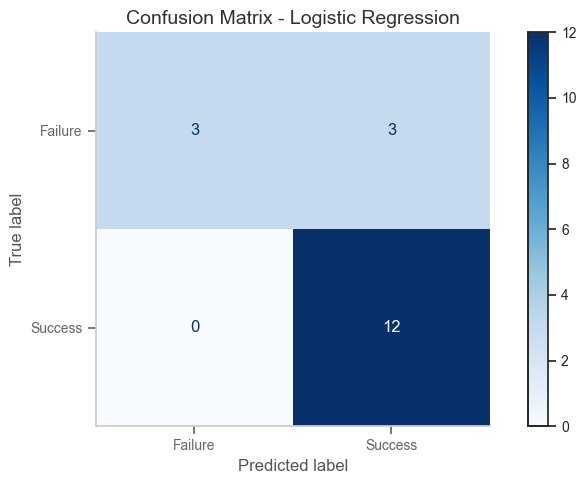

In [55]:
# Display the confusion matrix for the selected model

with sns.axes_style("ticks"):
    cm = confusion_matrix(y_test, y_pred_selected)
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, 
        display_labels=["Failure", "Success"]
    )
    
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {selected_model_name}")

    style_axes_text()
    
    save_figure("confusion_matrix_selected_model.png")

Logistic Regression and SVM can produce the same test accuracy on this relatively small dataset. This does not necessarily mean they are equally strong in every sense; it means they performed equally on this specific test split.

## 9. Interactive Dashboard

An interactive dashboard was created using Plotly Dash to allow users to explore SpaceX launch outcomes dynamically.

The dashboard includes:
- A launch site dropdown filter
- A payload mass range slider
- A pie chart showing successful launch counts by site
- A scatter plot showing the relationship between payload mass and launch outcome

Dashboard file: `dashboard/spacex_dash_app.py`

## 10. Key Insights

- Launch success rates vary across launch sites and orbit types, suggesting that operational and mission-specific factors matter.
- Payload mass alone does not clearly separate successful and failed landings, but it remains useful when combined with other mission variables.
- Rolling success rate improves over time, reflecting SpaceX's engineering iteration and operational learning.
- Geographic analysis shows that launch sites are close to coastlines while maintaining access to transportation infrastructure.
- Logistic Regression and SVM achieved the same test accuracy in this run; Logistic Regression is selected as the final model because it is simpler and easier to interpret.

## 11. Conclusion

This project demonstrates a complete data science workflow using SpaceX Falcon 9 launch data.

The workflow includes:
- Collecting structured launch data from the SpaceX API and supplementary data from Wikipedia
- Cleaning and preparing data for analysis and modeling
- Performing EDA with consistent visual design and clear insights
- Running SQL-style analysis with SQLite
- Visualizing launch-site geography and infrastructure proximity
- Training and evaluating classification models

Overall, the analysis shows that Falcon 9 landing success is influenced by a combination of launch site, orbit type, payload mass, flight sequence, and booster-related features. 